In [1]:
import time
import math

In [2]:
sensor='/sys/bus/iio/devices/iio:device0/in_voltage0_raw'

In [23]:
# Parameters
sampling_rate = 1000  # 8 kHz
chunk_size = 100  # Process in chunks of 1000 samples
total_samples = sampling_rate * 10  # Total samples for 10 seconds

# Initialize variables for incremental RMS calculation
sample_count = 0
sum_squares = 0

# Function to read ADC value from the file
def read_adc():
    with open(sensor, 'r') as f:
        return int(f.read().strip())

def read_adc_file(file):
    file.seek(0)  # Move to the beginning of the file
    return int(file.read().strip())

# Function to incrementally update the RMS calculation
def update_rms(new_sample, count, sum_squares):
    # Update the cou
    count += 1
    # Update the sum of squares
    sum_squares += (new_sample - 512) ** 2
    # Compute the current RMS
    rms = math.sqrt(sum_squares / count)
    return count, sum_squares, rms

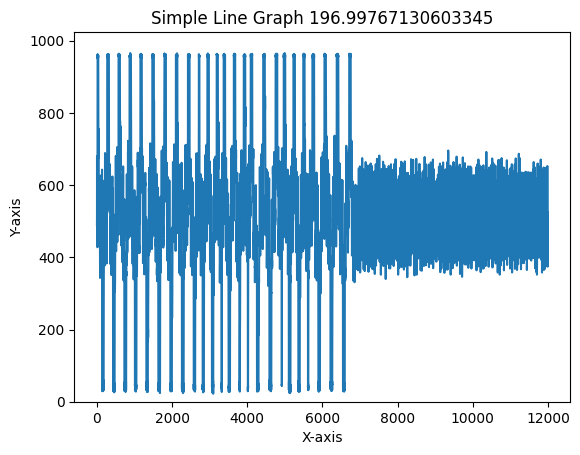

Stopped by user


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import clear_output


# Main loop
want_samples = 12000
acc = [1024] * want_samples
try:
    plt.ion()  # Turn on interactive mode
    fig, ax = plt.subplots()
    adc_file = open(sensor, 'r')

    for cur_cycle in range(500):
        start_time = time.time()
        sample_count = 0
        sum_squares = 0
        
        for i in range(want_samples):
            adc_value = read_adc_file(adc_file)
            acc[i] = adc_value
            sample_count, sum_squares, rms = update_rms(adc_value, sample_count, sum_squares)
            #time.sleep(0.001)

        # plot
        ax.clear()
        print(f"Time elapsed to collect samples: {time.time()-start_time}, rms: {rms}")
        
        # Generate x-values (0, 1, 2, ..., len(data)-1)
        x_values = list(range(len(acc)))
        
        # Create the line plot
        sns.lineplot(x=x_values, y=acc)
        
        # Add labels and title
        plt.ylim(0, 1024)
        plt.xlabel('X-axis')
        plt.ylabel('Y-axis')
        plt.title(f'Simple Line Graph {rms}')
        
        # Display the plot
        #plt.draw()
        #plt.pause(1)
        clear_output(wait=True)
        plt.show()
        #print(sorted(acc))
        #break

except KeyboardInterrupt:
    print("Stopped by user")

In [ ]:
# Main loop
try:
    while True:
        start_time = time.time()
        
        for _ in range(total_samples // chunk_size):
            for _ in range(chunk_size):
                adc_value = read_adc()
                sample_count, sum_squares, rms = update_rms(adc_value, sample_count, sum_squares)
                time.sleep(1 / sampling_rate)
        
        # Print loudness every 10 seconds
        print(f"Loudness: {rms}")
        
        # Reset for the next interval
        sample_count = 0
        sum_squares = 0
        
        # Ensure loop runs every 10 seconds
        time_to_wait = 10 - (time.time() - start_time)
        if time_to_wait > 0:
            time.sleep(time_to_wait)

except KeyboardInterrupt:
    print("Stopped by user")

# Pyaudio

In [20]:
import pyaudio
import numpy as np
import scipy.fftpack
import time

Recording...
Finished recording.


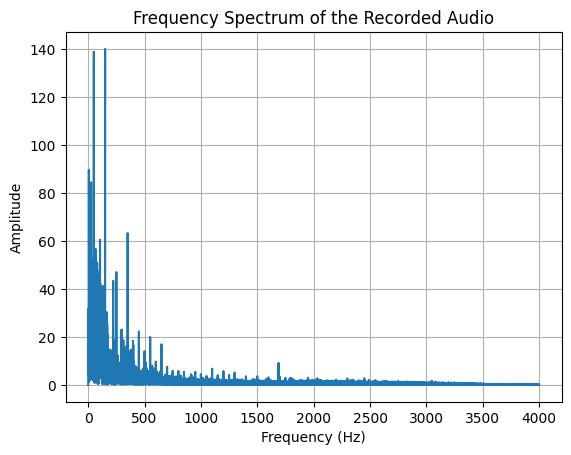

In [21]:
# Parameters
FORMAT = pyaudio.paInt16  # 16-bit resolution
CHANNELS = 1              # Mono channel
RATE = 8000               # Sampling rate
CHUNK = 1024              # Number of samples per frame
RECORD_SECONDS = 10       # Duration to record

# Initialize PyAudio
audio = pyaudio.PyAudio()

# Open the stream
stream = audio.open(format=FORMAT,
                    channels=CHANNELS,
                    rate=RATE,
                    input=True,
                    frames_per_buffer=CHUNK)

print("Recording...")

frames = []

# Record for the specified duration
for i in range(0, int(RATE / CHUNK * RECORD_SECONDS)):
    data = stream.read(CHUNK)
    frames.append(np.frombuffer(data, dtype=np.int16))

print("Finished recording.")

# Stop and close the stream
stream.stop_stream()
stream.close()
audio.terminate()

# Convert frames to a single numpy array
signal = np.hstack(frames)

# Remove DC bias (assuming 0 as bias for simplicity)
signal = signal - np.mean(signal)

# Perform FFT
N = len(signal)
T = 1.0 / RATE
yf = scipy.fftpack.fft(signal)
xf = np.linspace(0.0, 1.0 / (2.0 * T), N // 2)

# Plotting the results
import matplotlib.pyplot as plt

plt.figure()
plt.plot(xf, 2.0 / N * np.abs(yf[:N // 2]))
plt.grid()
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency Spectrum of the Recorded Audio")
plt.show()

Recording...
Recording complete.


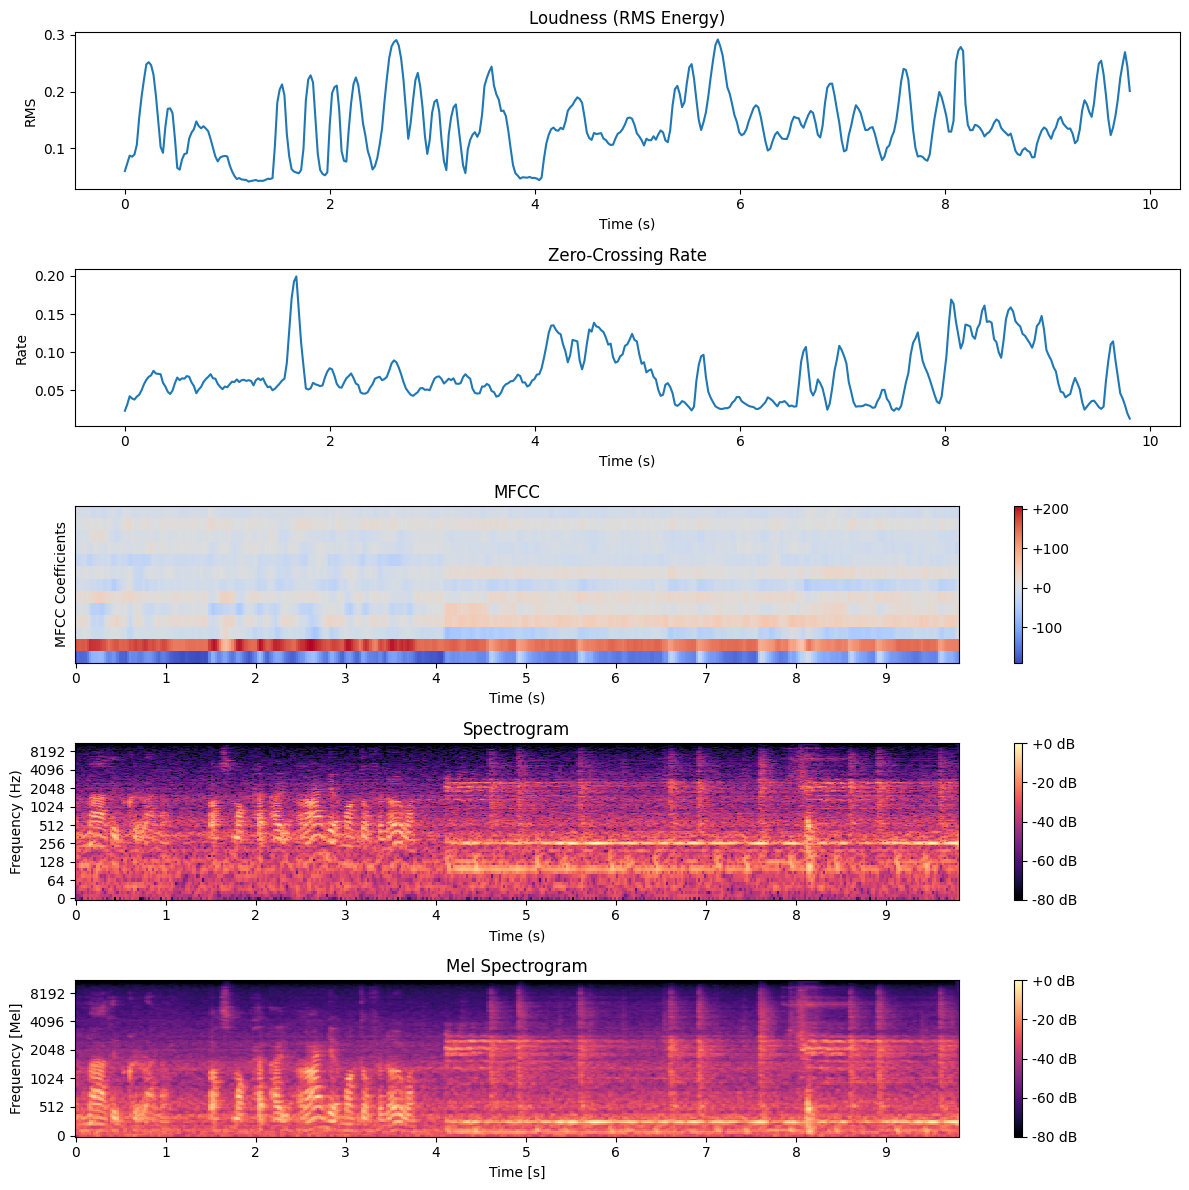

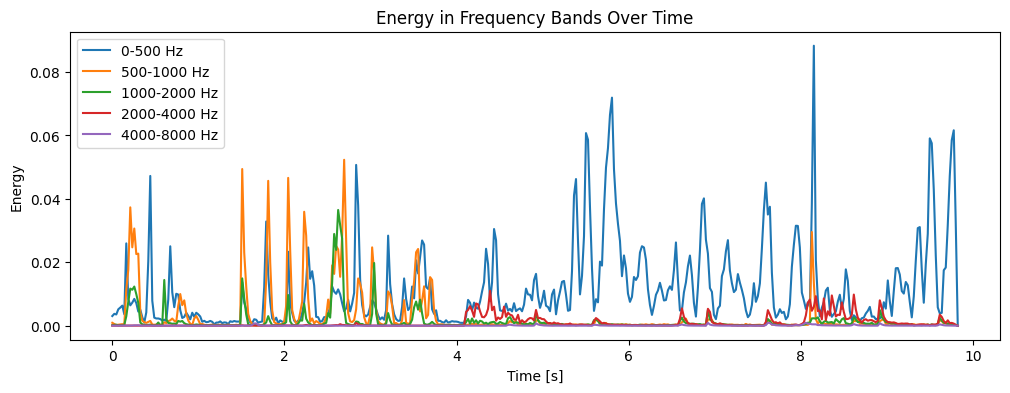

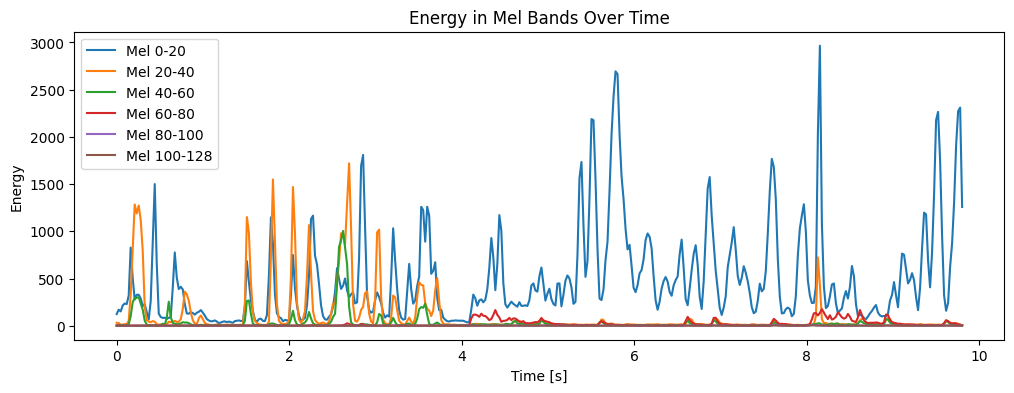

Band 1 (0-500 Hz): 0.01
Band 2 (500-1000 Hz): 0.00
Band 3 (1000-2000 Hz): 0.00
Band 4 (2000-4000 Hz): 0.00
Band 5 (4000-8000 Hz): 0.00


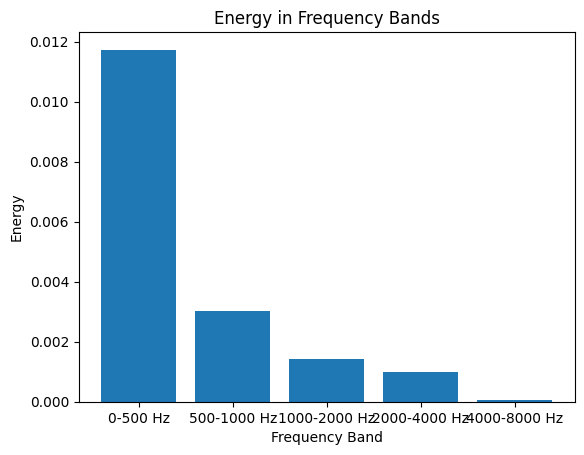

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import pyaudio
import numpy as np
import scipy.fftpack
import time
import sounddevice as sd
from scipy.signal import get_window
from scipy.signal import stft

# Settings
duration = 10  # seconds
sampling_rate = 22050  # Hz
strip_duration = 0.2  # Duration to strip from the beginning in seconds

# Capture audio from the microphone
print("Recording...")
audio = sd.rec(int(duration * sampling_rate), samplerate=sampling_rate, channels=1, dtype='float32')
sd.wait()
audio = audio.flatten()
print("Recording complete.")

# Strip the first 0.2 seconds from the recording
strip_samples = int(strip_duration * sampling_rate)
audio = audio[strip_samples:]

# Compute loudness (RMS energy)
frame_length = 2048
hop_length = 512
n_mels = 128  # Number of Mel bands
rms = librosa.feature.rms(y=audio, frame_length=frame_length, hop_length=hop_length)[0]

# Compute zero-crossing rate
zero_crossings = librosa.feature.zero_crossing_rate(y=audio, frame_length=frame_length, hop_length=hop_length)[0]

# Compute MFCCs
mfccs = librosa.feature.mfcc(y=audio, sr=sampling_rate, n_mfcc=13, hop_length=hop_length)

# Compute spectrogram
D = librosa.amplitude_to_db(np.abs(librosa.stft(audio, n_fft=frame_length, hop_length=hop_length)), ref=np.max)

# Compute mel spectrogram
mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=sampling_rate, hop_length=hop_length, n_mels=128)

# Convert power spectrogram (amplitude squared) to decibel (dB) units
mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

# Sum the energy in each mel band over time
band_energies = np.sum(mel_spectrogram, axis=0)

# Compute frequency band energy
mel_bands_spec = [0, 20, 40, 60, 80, 100, 128]
mel_bands = [(mel_bands_spec[i], mel_bands_spec[i+1]) for i in range(len(mel_bands_spec)-1)]
bands = [0, 500, 1000, 2000, 4000, 8000]  # Hz
band_energies = []
band_energies_timed = []
frequency_bands = []
mel_band_energies = []

# Compute Short-Time Fourier Transform (STFT)
frequencies, times, Zxx = stft(audio, fs=sampling_rate, nperseg=1024)

for i in range(len(bands) - 1):
    # Get indices of frequencies within the current band
    band = bands[i], bands[i+1]
    frequency_bands.append(band)
    band_indices = np.where((frequencies >= band[0]) & (frequencies < band[1]))[0]
    
    # Sum the magnitudes squared (energy) for frequencies within the band
    band_energy2 = np.sum(np.abs(Zxx[band_indices, :])**2, axis=0)
    band_energies_timed.append(band_energy2)
    
    # Average energy over time
    average_band_energy = np.mean(band_energy2)
    band_energies.append(average_band_energy)

# Compute the energy for each mel band as a function of time
for band in mel_bands:
    # Sum the magnitudes squared (energy) for frequencies within the band
    band_energy = np.sum(mel_spectrogram[band[0]:band[1], :], axis=0)
    mel_band_energies.append(band_energy)

# Plot the results
plt.figure(figsize=(12, 12))

# Plot loudness
plt.subplot(5, 1, 1)
plt.plot(librosa.times_like(rms, sr=sampling_rate, hop_length=hop_length), rms)
plt.title('Loudness (RMS Energy)')
plt.xlabel('Time (s)')
plt.ylabel('RMS')

# Plot zero-crossing rate
plt.subplot(5, 1, 2)
plt.plot(librosa.times_like(zero_crossings, sr=sampling_rate, hop_length=hop_length), zero_crossings)
plt.title('Zero-Crossing Rate')
plt.xlabel('Time (s)')
plt.ylabel('Rate')

# Plot MFCCs
plt.subplot(5, 1, 3)
librosa.display.specshow(mfccs, sr=sampling_rate, x_axis='time', hop_length=hop_length)
plt.colorbar(format='%+2.0f')
plt.title('MFCC')
plt.xlabel('Time (s)')
plt.ylabel('MFCC Coefficients')

# Plot spectrogram
plt.subplot(5, 1, 4)
librosa.display.specshow(D, sr=sampling_rate, x_axis='time', y_axis='log', hop_length=hop_length)
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
#plt.tight_layout()
#plt.show()

# Plot the mel spectrogram
#plt.figure(figsize=(12, 3))
plt.subplot(5, 1, 5)
librosa.display.specshow(mel_spectrogram_db, sr=sampling_rate, hop_length=hop_length, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram')
plt.xlabel('Time [s]')
plt.ylabel('Frequency [Mel]')
plt.tight_layout()
plt.show()

# Plot band energies as a function of time
plt.figure(figsize=(12, 4))
#plt.subplot(5, 1, 3)
for i, (band, energy) in enumerate(zip(frequency_bands, band_energies_timed)):
    plt.plot(times, energy, label=f'{band[0]}-{band[1]} Hz')
plt.xlabel('Time [s]')
plt.ylabel('Energy')
plt.title('Energy in Frequency Bands Over Time')
plt.legend()
plt.show()

# Plot the energy in each mel band over time
plt.figure(figsize=(12, 4))
#plt.subplot(5, 1, 3)
for i, (band, energy) in enumerate(zip(mel_bands, mel_band_energies)):
    plt.plot(np.arange(len(energy)) * hop_length / sampling_rate, energy, label=f'Mel {band[0]}-{band[1]}')
plt.xlabel('Time [s]')
plt.ylabel('Energy')
plt.title('Energy in Mel Bands Over Time')
plt.legend()
plt.show()

# Print band energies
for i, (band, energy) in enumerate(zip(frequency_bands, band_energies)):
    print(f"Band {i+1} ({band[0]}-{band[1]} Hz): {energy:.2f}")

# Plot band energies
band_labels = [f'{band[0]}-{band[1]} Hz' for band in frequency_bands]
plt.bar(band_labels, band_energies)
plt.xlabel('Frequency Band')
plt.ylabel('Energy')
plt.title('Energy in Frequency Bands')
plt.show()

# Examples

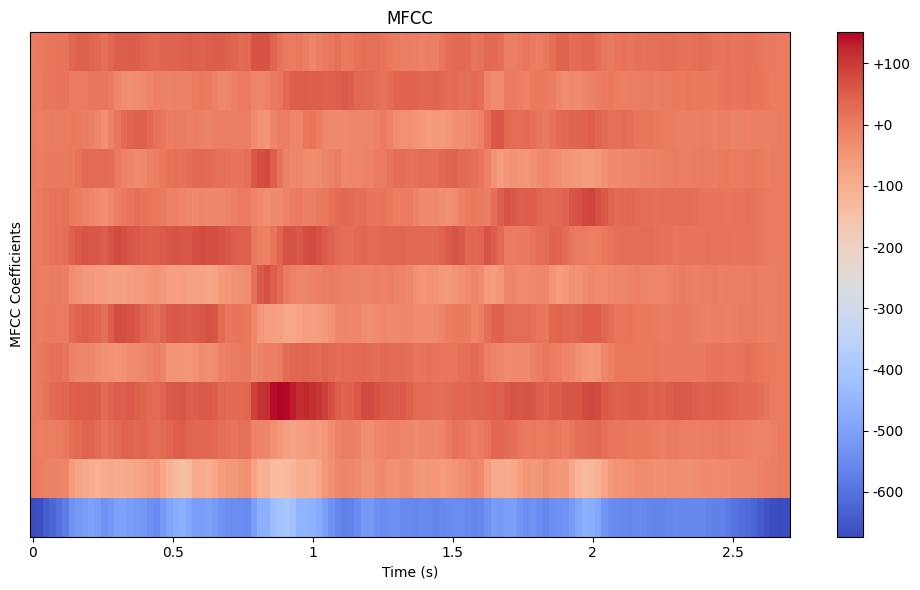

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

# Load an example audio file
y, sr = librosa.load(librosa.ex('robin'))

# Compute MFCCs
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

# Display MFCCs
plt.figure(figsize=(10, 6))
librosa.display.specshow(mfccs, sr=sr, x_axis='time')
plt.colorbar(format='%+2.0f')
plt.title('MFCC')
plt.xlabel('Time (s)')
plt.ylabel('MFCC Coefficients')
plt.tight_layout()
plt.show()

In [69]:
import numpy as np
import librosa
import sounddevice as sd
from scipy.signal import stft
import time
import requests
import json

# Function to send metrics to Grafana
def send_to_grafana(metrics):
    def convert_metrics(value):
        if isinstance(value, np.ndarray):
            return value.tolist()
        elif isinstance(value, (np.float32, np.float64, np.int32, np.int64)):
            return value.item()
        elif isinstance(value, list):
            return [convert_metrics(item) for item in value]
        elif isinstance(value, dict):
            return {k: convert_metrics(v) for k, v in value.items()}
        else:
            return value

    metrics_serializable = convert_metrics(metrics)
    print(json.dumps(metrics_serializable, indent=2))
    # url = "http://<YOUR_GRAFANA_INSTANCE>/api/datasources/proxy/<YOUR_DATASOURCE_ID>/api/v1/write"
    # headers = {
    #     'Authorization': 'Bearer <YOUR_GRAFANA_API_KEY>',
    #     'Content-Type': 'application/json'
    # }
    # data = {
    #     "metrics": metrics
    # }
    # response = requests.post(url, headers=headers, json=data)
    # return response.status_code

# Parameters
sampling_rate = 22050  # Hz
strip_duration = 0.2  # Duration to strip from the beginning in seconds
frame_length = 2048
hop_length = 512
n_mels = 128  # Number of Mel bands
bands = [0, 500, 1000, 2000, 4000, 8000]  # Hz
mel_bands_spec = [0, 20, 40, 60, 80, 100, 128]
mel_bands = [(mel_bands_spec[i], mel_bands_spec[i+1]) for i in range(len(mel_bands_spec)-1)]
aggregation_type = 'mean'  # Can be 'mean' or 'max'

# Function to compute metrics from audio data
def compute_metrics(audio):
    # Strip the first 0.2 seconds from the recording
    strip_samples = int(strip_duration * sampling_rate)
    audio = audio[strip_samples:]

    # Compute loudness (RMS energy)
    rms = librosa.feature.rms(y=audio, frame_length=frame_length, hop_length=hop_length)[0]

    # Compute zero-crossing rate
    zero_crossings = librosa.feature.zero_crossing_rate(y=audio, frame_length=frame_length, hop_length=hop_length)[0]

    # Compute MFCCs
    mfccs = librosa.feature.mfcc(y=audio, sr=sampling_rate, n_mfcc=13, hop_length=hop_length)

    # Compute mel spectrogram
    mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=sampling_rate, hop_length=hop_length, n_mels=n_mels)

    # Compute the energy for each mel band as a function of time
    mel_band_energies = []
    for band in mel_bands:
        band_energy = np.sum(mel_spectrogram[band[0]:band[1], :], axis=0)
        mel_band_energies.append(band_energy)

    # Compute Short-Time Fourier Transform (STFT)
    frequencies, times, Zxx = stft(audio, fs=sampling_rate, nperseg=1024)
    
    # Compute the energy for each frequency band as a function of time
    band_energies_timed = []
    for i in range(len(bands) - 1):
        band_indices = np.where((frequencies >= bands[i]) & (frequencies < bands[i+1]))[0]
        band_energy2 = np.sum(np.abs(Zxx[band_indices, :])**2, axis=0)
        band_energies_timed.append(band_energy2)

    return {
        'rms': rms,
        'zero_crossings': zero_crossings,
        'mfccs': mfccs,
        'mel_band_energies': mel_band_energies,
        'band_energies_timed': band_energies_timed,
        'times': times
    }

# Function to aggregate metrics
def aggregate_metrics(metrics_list, aggregation_type):
    aggregated_metrics = {
        'rms': [],
        'zero_crossings': [],
        'mfccs': None,
        'mel_band_energies': [],
        'band_energies_timed': []
    }
    
    for metrics in metrics_list:
        for key in aggregated_metrics.keys():
            if key == 'mfccs':
                if aggregated_metrics[key] is None:
                    aggregated_metrics[key] = metrics[key]
                else:
                    aggregated_metrics[key] = np.hstack((aggregated_metrics[key], metrics[key]))
            else:
                aggregated_metrics[key].append(metrics[key])
    
    for key, value in aggregated_metrics.items():
        if key == 'mfccs':
            if aggregation_type == 'mean':
                aggregated_metrics[key] = np.mean(aggregated_metrics[key], axis=1)
            else:
                aggregated_metrics[key] = np.max(aggregated_metrics[key], axis=1)
        else:
            if isinstance(value[0], list):
                aggregated_metrics[key] = [np.mean(v) if aggregation_type == 'mean' else np.max(v) for v in zip(*value)]
            else:
                if key == 'rms' or key == 'zero_crossings':
                    aggregated_metrics[key] = np.mean(value) if aggregation_type == 'mean' else np.max(value)
                else:
                    aggregated_metrics[key] = np.mean(value, axis=0) if aggregation_type == 'mean' else np.max(value, axis=0)
    
    return aggregated_metrics

# Continuous sampling and processing
while True:
    start_time = time.time()
    metrics_list = []

    while time.time() - start_time < 10:
        # Capture audio for a short duration
        duration = 1  # Capture 1 second of audio at a time
        audio = sd.rec(int(duration * sampling_rate), samplerate=sampling_rate, channels=1, dtype='float32')
        sd.wait()
        audio = audio.flatten()

        # Compute metrics
        metrics = compute_metrics(audio)
        metrics_list.append(metrics)

    # Aggregate metrics over 1 minute
    aggregated_metrics = aggregate_metrics(metrics_list, aggregation_type)

    # Send metrics to Grafana
    response_code = send_to_grafana(aggregated_metrics)
    print(f"Metrics sent to Grafana with response code {response_code}")

{
  "rms": 0.016726020723581314,
  "zero_crossings": 0.05804443359375,
  "mfccs": [
    -309.66912841796875,
    87.84046936035156,
    24.28888702392578,
    38.09676742553711,
    7.813408374786377,
    24.609413146972656,
    1.2546749114990234,
    16.064424514770508,
    -0.7723270654678345,
    12.110095024108887,
    -3.0505664348602295,
    8.566765785217285,
    -0.7107450366020203
  ],
  "mel_band_energies": [
    8.266809463500977,
    0.12132444232702255,
    0.041691165417432785,
    0.02107136882841587,
    0.014489194378256798,
    0.009669356979429722
  ],
  "band_energies_timed": [
    0.00021011987701058388,
    3.1422734991792822e-06,
    1.7803415630623931e-06,
    1.6456465345981997e-06,
    2.0135166778345592e-06
  ]
}
Metrics sent to Grafana with response code None
{
  "rms": 0.016027791425585747,
  "zero_crossings": 0.057216099330357144,
  "mfccs": [
    -310.80242919921875,
    86.90280151367188,
    23.72279167175293,
    37.92647933959961,
    8.0893802642822

KeyboardInterrupt: 